In [2]:
!pip install -q gradio scikit-learn pandas numpy

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

import gradio as gr

In [3]:
from io import StringIO
import pandas as pd

data_text="""query_id,score,decision,anomaly_ratio,badge_age_days,clearance_level,escorts,history_score,linked_badges,recent_denials,requested_zone,site,tenure_years
4 · 1	0.9876	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.2
R2 · 31	0.3098	DECLINE	0	75	37	0	300	0	5	100	A	0
R2 · 30	0.4567	APPROVE	0	75	37	0	300	0	5	100	A	40
R2 · 29	0.4608	APPROVE	0	75	37	0	300	0	5	100	D	40
R2 · 28	0.4564	APPROVE	0	75	37	0	300	0	5	100	B	40
R2 · 27	0.3022	DECLINE	0	75	37	0	300	0	5	100	C	0
R2 · 26	0.4501	APPROVE	0	75	37	0	300	0	5	100	C	37.2
R2 · 25	0.4475	DECLINE	0	75	37	0	300	0	5	100	A	37.2
R2 · 24	0.8944	APPROVE	0	75	37	0	300	20	5	0	A	37.2
R2 · 23	0.2088	DECLINE	0	75	37	0	900	0	5	0	A	37.2
R2 · 22	0.4672	APPROVE	0	75	37	0	900	20	5	100	A	37.2
R2 · 21	0.5920	APPROVE	0	75	37	0	300	0	5	0	A	37.2
R2 · 20	0.4475	DECLINE	0	75	37	0	300	0	5	100	A	37.2
R2 · 19	0.4475	DECLINE	0	75	100	0	300	0	5	100	A	37.2
R2 · 18	0.8944	APPROVE	0	75	100	0	300	20	5	0	A	37.2
R2 · 17	0.5920	APPROVE	0	75	100	0	300	0	5	0	A	37.2
R2 · 16	0.8583	APPROVE	0	75	100	0	300	20	5	100	A	37.2
R2 · 15	0.8974	APPROVE	0	75	100	0	300	17.9	5	4.5	A	37.2
R2 · 14	0.9458	APPROVE	0	18	100	6	300	17.9	5	4.5	A	37.2
R2 · 13	0.8974	APPROVE	0	75	100	6	300	17.9	5	4.5	A	37.2
R2 · 12	0.9458	APPROVE	0	18	100	0	300	17.9	5	4.5	A	37.2
R2 · 11	0.8658	APPROVE	0	18	100	0	900	17.9	0	4.5	A	37.2
R2 · 10	0.7638	APPROVE	0	18	100	0	900	17.9	5	4.5	A	37.2
R2 · 9	0.9876	APPROVE	0	18	100	0	300	17.9	0	4.5	A	37.2
R2 · 8	0.9876	APPROVE	0	18	100	0	300	17.9	0	4.5	A	37.2
R2 · 7	0.9876	APPROVE	1	18	0	0	300	17.9	0	4.5	A	37.2
R2 · 6	0.9876	APPROVE	0	18	0	0	300	17.9	0	4.5	A	37.2
R2 · 5	0.9876	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.2
R2 · 4	0.8213	APPROVE	0.105	46.5	50	3	600	10	2.5	50	A	20
R2 · 3	0.8213	APPROVE	0.59	46.5	50	3	600	10	2.5	50	A	20
R2 · 2	0.8213	APPROVE	0.5	46.5	50	3	600	10	2.5	50	A	20
R2 · 1	0.8213	APPROVE	1	46.5	50	3	600	10	2.5	50	A	20
R1 · 45	0.9876	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 44	0.9812	APPROVE	1	18	100	6	300	17.9	0	4.5	D	37.2
R1 · 43	0.9876	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 42	0.9871	APPROVE	1	18	100	6	300	17.9	0	4.5	A	36.8
R1 · 41	0.9876	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 40	0.9875	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.8
R1 · 39	0.9875	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.8
R1 · 38	0.9871	APPROVE	1	18	100	6	300	17.9	0	4.5	A	36.8
R1 · 37	0.9876	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 36	0.8658	APPROVE	1	18	100	6	900	17.9	0	4.5	A	37.2
R1 · 35	0.9876	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 34	0.9865	APPROVE	1	18	100	6	300	17	0	4.5	A	37.2
R1 · 33	0.9876	APPROVE	1	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 32	0.9876	APPROVE	0	18	100	6	300	17.9	0	4.5	A	37.2
R1 · 31	0.9876	APPROVE	0	18	100	0	300	17.9	0	4.5	A	37.2
R1 · 30	0.9876	APPROVE	0	18	100	0	300	17.9	0	4.5	A	37.2
R1 · 29	0.9610	APPROVE	0	18	100	0	300	17.9	0	100	A	37.2
R1 · 28	0.9876	APPROVE	0	18	100	0	300	17.9	0	4.5	A	37.2
R1 · 27	0.9876	APPROVE	0	18	100	0	300	17.9	0	4.5	A	37.2
R1 · 26	0.9876	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.2
R1 · 25	0.9871	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	36.4
R1 · 24	0.9875	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.8
R1 · 23	0.9853	APPROVE	0.105	18	100	0	300	17.9	0	4.5	C	37.8
R1 · 22	0.9873	APPROVE	0.105	18	100	0	300	17.9	0	4.5	B	37.8
R1 · 21	0.9875	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.8
R1 · 20	0.9871	APPROVE	0.105	18	100	0	300	18.6	0	4.5	A	37.8
R1 · 19	0.9875	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.8
R1 · 18	0.8895	APPROVE	0.105	18	100	0	300	0	0	4.5	A	37.8
R1 · 17	0.9875	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.8
R1 · 16	0.9780	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	40
R1 · 15	0.9875	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.8
R1 · 14	0.9378	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	0
R1 · 13	0.9875	APPROVE	0.105	18	100	0	300	17.9	0	4.5	A	37.383
R1 · 12	0.9875	APPROVE	0.105	18	100	2.356	300	17.9	0	4.5	A	37.383
R1 · 11	0.9871	APPROVE	0.105	18	100	2.356	300	17.9	0	3	A	37.383
R1 · 10	0.9828	APPROVE	0.105	18	100	2.356	300	17.9	0	0	A	37.383
R1 · 9	0.9875	APPROVE	0.105	18	100	2.356	300	17.9	0	3.912	A	37.383
R1 · 8	0.9842	APPROVE	0.105	18	100	2.356	474	17.9	0	3.912	A	37.383
R1 · 7	0.9838	APPROVE	0.105	18	100	2.356	475.485	17.9	0	3.912	A	37.383
R1 · 6	0.9801	APPROVE	0.105	18	100	2.356	475.485	20	0	3.912	A	37.383
R1 · 5	0.9837	APPROVE	0.105	18	100	2.356	475.485	17.948	0	3.912	A	37.383
R1 · 4	0.9837	APPROVE	0.105	18	9.185	2.356	475.485	17.948	0	3.912	A	37.383
R1 · 3	0.9745	APPROVE	0.105	18	9.185	2.356	475.485	17.948	2.521	3.912	A	37.383
R1 · 2	0.9563	APPROVE	0.105	43.828	9.185	2.356	475.485	17.948	2.521	3.912	A	37.383
R1 · 1	0.9563	APPROVE	0.146	43.828	9.185	2.356	475.485
"""

# Split headers (comma-separated) and lines (tab-separated)
lines = data_text.strip().split('\n')
header = lines[0].split(',')
rows = [line.split('\t') for line in lines[1:]]

# Reconstruct DataFrame
df = pd.DataFrame(rows, columns=header)

# Keep query_id but clean numeric features
numeric_columns = [
    "clearance_level", "badge_age_days", "tenure_years",
    "anomaly_ratio", "escorts", "history_score",
    "linked_badges", "recent_denials", "requested_zone", "score"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Save clean dataset so graphs and models can easily load it
df.to_csv("/content/GK05_dataset.csv", index=False)

print("Dataset shape correctly parsed:", df.shape)
print("\nFirst few rows:")
display(df.head())

Dataset shape correctly parsed: (77, 13)

First few rows:


,query_id,score,decision,anomaly_ratio,badge_age_days,clearance_level,escorts,history_score,linked_badges,recent_denials,requested_zone,site,tenure_years
0,4 · 1,0.9876,APPROVE,0.105,18.0,100.0,0.0,300.0,17.9,0.0,4.5,A,37.2
1,R2 · 31,0.3098,DECLINE,0.000,75.0,37.0,0.0,300.0,0.0,5.0,100.0,A,0.0
2,R2 · 30,0.4567,APPROVE,0.000,75.0,37.0,0.0,300.0,0.0,5.0,100.0,A,40.0
3,R2 · 29,0.4608,APPROVE,0.000,75.0,37.0,0.0,300.0,0.0,5.0,100.0,D,40.0
4,R2 · 28,0.4564,APPROVE,0.000,75.0,37.0,0.0,300.0,0.0,5.0,100.0,B,40.0


In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   query_id         77 non-null     object 
 1   score            77 non-null     float64
 2   decision         77 non-null     object 
 3   anomaly_ratio    77 non-null     float64
 4   badge_age_days   77 non-null     float64
 5   clearance_level  77 non-null     float64
 6   escorts          77 non-null     float64
 7   history_score    77 non-null     float64
 8   linked_badges    76 non-null     float64
 9   recent_denials   76 non-null     float64
 10  requested_zone   76 non-null     float64
 11  site             76 non-null     object 
 12  tenure_years     76 non-null     float64
dtypes: float64(10), object(3)
memory usage: 7.9+ KB
None

Missing values:
query_id           0
score              0
decision           0
anomaly_ratio      0
badge_age_days     0
clearance_level    0
escort

In [5]:
import pandas as pd

# Reload the correctly formatted dataset
df = pd.read_csv("/content/GK05_dataset.csv")

print("\nDecision counts:")
print(df["decision"].value_counts())


Decision counts:
decision
APPROVE    71
DECLINE     6
Name: count, dtype: int64


In [6]:
features = [
    "anomaly_ratio",
    "badge_age_days",
    "clearance_level",
    "escorts",
    "history_score",
    "linked_badges",
    "recent_denials",
    "requested_zone",
    "site",
    "tenure_years"
]

In [ ]:
print(features)

['anomaly_ratio', 'badge_age_days', 'clearance_level', 'escorts', 'history_score', 'linked_badges', 'recent_denials', 'requested_zone', 'site', 'tenure_years']


In [7]:
import pandas as pd

# Load the clean dataset
data_df = pd.read_csv("/content/GK05_dataset.csv")

# Drop rows that are completely empty (like the last index 76)
data_df = data_df.dropna(subset=["decision"])

# Define target y ('decision') and features X
y = data_df["decision"]

# Define features to match the kDXI6LLnqNAZ list
features = [
    "anomaly_ratio",
    "badge_age_days",
    "clearance_level",
    "escorts",
    "history_score",
    "linked_badges",
    "recent_denials",
    "requested_zone",
    "site",
    "tenure_years"
]

X = data_df[features]

# Display metadata and sample values
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\nFirst X row:")
print(X.iloc[0])

print("\nFirst y value:")
print(y.iloc[0])

X shape: (77, 10)
y shape: (77,)

X columns:
['anomaly_ratio', 'badge_age_days', 'clearance_level', 'escorts', 'history_score', 'linked_badges', 'recent_denials', 'requested_zone', 'site', 'tenure_years']

First X row:
anomaly_ratio      0.105
badge_age_days      18.0
clearance_level    100.0
escorts              0.0
history_score      300.0
linked_badges       17.9
recent_denials       0.0
requested_zone       4.5
site                   A
tenure_years        37.2
Name: 0, dtype: object

First y value:
APPROVE


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Clean data and handle any NaNs in the target
data_clean = data_df.dropna(subset=["decision"])

# 2. Extract features and target
y = data_clean["decision"]
X = data_clean[features]

# 3. Perform a train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Define preprocessor for handling categorical variables ('site') and numericals
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["site"])
    ],
    remainder="passthrough"
)

# 5. Define and train the pipeline model
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)

# 6. Generate and print predictions
predicted_scores = model.predict(X_test)
print("Predicted decisions:")
print(predicted_scores)

# Print accuracy as validation
accuracy = model.score(X_test, y_test)
print(f"\nModel Test Accuracy: {accuracy * 100:.2f}%")

Predicted decisions:
['APPROVE' 'APPROVE' 'APPROVE' 'APPROVE' 'APPROVE' 'APPROVE' 'APPROVE'
 'APPROVE' 'APPROVE' 'APPROVE' 'DECLINE' 'APPROVE' 'APPROVE' 'APPROVE'
 'APPROVE' 'APPROVE']

Model Test Accuracy: 87.50%


Reconstructed Model Test:
Score: 1.0
Decision: APPROVE
--------------------------------------------------

Feature Importances:
                       Feature  Importance
10    remainder__linked_badges    0.207623
12   remainder__requested_zone    0.197060
13     remainder__tenure_years    0.169035
7   remainder__clearance_level    0.125068
9     remainder__history_score    0.067429
6    remainder__badge_age_days    0.062829
0                  cat__site_A    0.056732
11   remainder__recent_denials    0.039436
2                  cat__site_C    0.029643
1                  cat__site_B    0.022061
5     remainder__anomaly_ratio    0.014460
8           remainder__escorts    0.008623
4                cat__site_nan    0.000000
3                  cat__site_D    0.000000


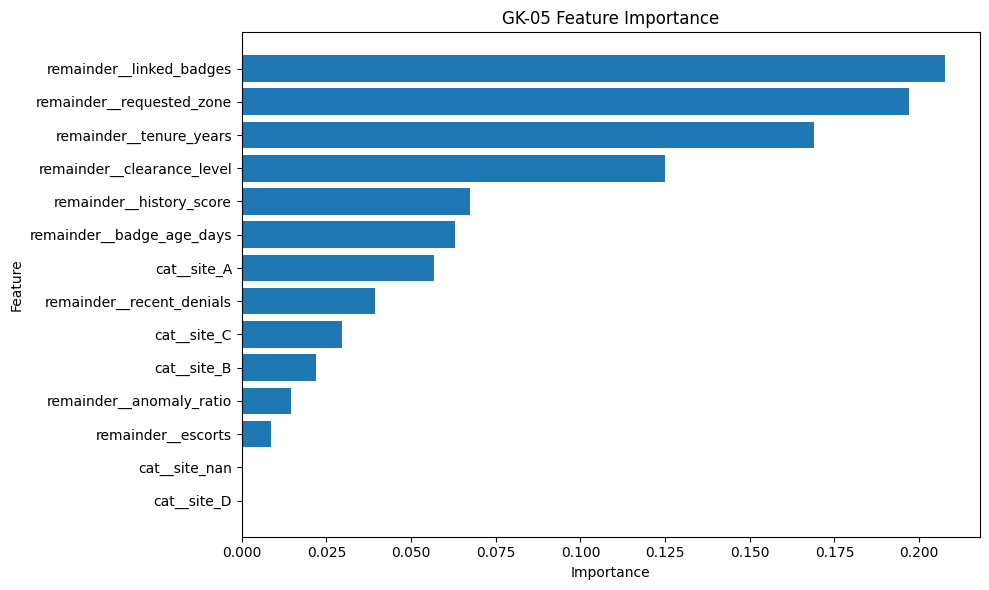


Full Dataset Decision Accuracy: 97.40%
Model saved as GK05_reconstructed_model.pkl successfully!
Results saved as GK05_reconstruction_results.csv successfully!


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import joblib

# 1. Define the reconstructed model helper function
def reconstructed_gk05(anomaly_ratio, badge_age_days, clearance_level, escorts,
                       history_score, linked_badges, recent_denials, requested_zone,
                       site, tenure_years):
    # Wrap input features in a DataFrame with correct feature names
    input_data = pd.DataFrame([{
        "anomaly_ratio": anomaly_ratio,
        "badge_age_days": badge_age_days,
        "clearance_level": clearance_level,
        "escorts": escorts,
        "history_score": history_score,
        "linked_badges": linked_badges,
        "recent_denials": recent_denials,
        "requested_zone": requested_zone,
        "site": site,
        "tenure_years": tenure_years
    }])

    # Predict binary decision ('APPROVE' or 'DECLINE')
    decision = model.predict(input_data)[0]
    # Extract probability score for 'APPROVE'
    score = model.predict_proba(input_data)[0][0] # Index 0 corresponds to APPROVE depending on class order

    return score, decision

# 2. Test the reconstructed function
score, decision = reconstructed_gk05(
    anomaly_ratio=0,
    badge_age_days=25,
    clearance_level=100,
    escorts=6,
    history_score=350,
    linked_badges=18,
    recent_denials=0,
    requested_zone=37,
    site="A",
    tenure_years=35
)
print("Reconstructed Model Test:")
print("Score:", round(score, 4))
print("Decision:", decision)
print("-" * 50)

# 3. Retrieve feature importances from classifier
clf = model.named_steps["classifier"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
importance = clf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df)

# 4. Plot Feature Importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("GK-05 Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Generate and save predictions comparison table
results = df.copy()
# Clean any NaNs in 'decision'
results = results.dropna(subset=["decision"])

results["predicted_decision"] = model.predict(results[features])
decision_accuracy = accuracy_score(results["decision"], results["predicted_decision"])

print(f"\nFull Dataset Decision Accuracy: {decision_accuracy * 100:.2f}%")

# Save model and results
joblib.dump(model, "GK05_reconstructed_model.pkl")
print("Model saved as GK05_reconstructed_model.pkl successfully!")

results.to_csv("GK05_reconstruction_results.csv", index=False)
print("Results saved as GK05_reconstruction_results.csv successfully!")

In [ ]:
predicted_scores = model.predict(X_test)

print("Predicted scores:")
print(predicted_scores)

Predicted scores:
['APPROVE' 'APPROVE' 'APPROVE' 'APPROVE' 'APPROVE' 'APPROVE' 'APPROVE'
 'APPROVE' 'APPROVE' 'APPROVE' 'DECLINE' 'APPROVE' 'APPROVE' 'APPROVE'
 'APPROVE' 'APPROVE']


In [ ]:
score, decision = reconstructed_gk05(
    0,
    24,
    100,
    6,
    350,
    18,
    0,
    37,
    "A",
    34
)

print("Reconstructed GK-05")
print("-------------------")
print("Score:", round(score, 4))
print("Decision:", decision)

Reconstructed GK-05
-------------------
Score: 1.0
Decision: APPROVE


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the trained Random Forest classifier (fixed step name)
rf = model.named_steps["classifier"]

# Get the actual feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importance = rf.feature_importances_

# Create table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(importance_df)

                       Feature  Importance
10    remainder__linked_badges    0.207623
12   remainder__requested_zone    0.197060
13     remainder__tenure_years    0.169035
7   remainder__clearance_level    0.125068
9     remainder__history_score    0.067429
6    remainder__badge_age_days    0.062829
0                  cat__site_A    0.056732
11   remainder__recent_denials    0.039436
2                  cat__site_C    0.029643
1                  cat__site_B    0.022061
5     remainder__anomaly_ratio    0.014460
8           remainder__escorts    0.008623
4                cat__site_nan    0.000000
3                  cat__site_D    0.000000


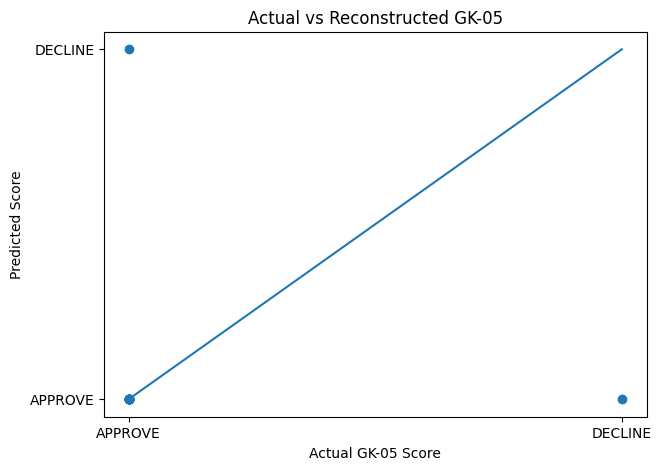

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    predicted_scores
)

plt.xlabel("Actual GK-05 Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Reconstructed GK-05")

plt.plot([0, 1], [0, 1])

plt.show()

In [ ]:
# Drop rows with NaN in decision to avoid prediction mismatches
clean_df = df.dropna(subset=["decision"]).copy()
X_clean = clean_df[features]

# Get predicted class decisions ('APPROVE' or 'DECLINE')
predicted_decisions = model.predict(X_clean)

# Get probability scores for 'APPROVE'
# model.classes_[0] is typically 'APPROVE' and model.classes_[1] is 'DECLINE'
approve_class_idx = list(model.classes_).index("APPROVE")
predicted_probs = model.predict_proba(X_clean)[:, approve_class_idx]

# Assemble results
results = clean_df[[
    "query_id",
    "score",
    "decision"
]].copy()

results["predicted_score"] = predicted_probs
results["predicted_decision"] = predicted_decisions

display(results)

,query_id,score,decision,predicted_score,predicted_decision
0,4 · 1,0.9876,APPROVE,1.00,APPROVE
1,R2 · 31,0.3098,DECLINE,0.05,DECLINE
2,R2 · 30,0.4567,APPROVE,0.27,DECLINE
3,R2 · 29,0.4608,APPROVE,0.66,APPROVE
4,R2 · 28,0.4564,APPROVE,0.82,APPROVE
...,...,...,...,...,...
72,R1 · 5,0.9837,APPROVE,1.00,APPROVE
73,R1 · 4,0.9837,APPROVE,1.00,APPROVE
74,R1 · 3,0.9745,APPROVE,1.00,APPROVE
75,R1 · 2,0.9563,APPROVE,1.00,APPROVE
